In [1]:
# Make repo root importable for this session (zero packaging)
import sys, pathlib
repo_root = pathlib.Path.cwd().parent if (pathlib.Path.cwd().name == "quickstart") else pathlib.Path.cwd()
sys.path.insert(0, str(repo_root))
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import math
import time
from datetime import datetime
import os
import shutil # for copying checkpoint to "last"
from pathlib import Path
import gc

import torch
import torch.nn as nn
import torchvision.transforms as transform

from torch.utils.tensorboard import SummaryWriter
import matplotlib.pylab as plt
%matplotlib inline
from IPython.display import Audio

from rnencodec.utils.utils import param_breakdown
from rnencodec.utils.io import save_run_config

from rnencodec.audioDataLoader.audio_dataset import LatentDatasetConfig, EnCodecLatentDataset_constant, EnCodecLatentDataset_dynamic, latents_to_audio_simple, efficient_codes_to_latents
from torch.utils.data import DataLoader

import rnencodec.model.gru_audio_model
from rnencodec.model.gru_audio_model import GRUModelConfig

from transformers import EncodecModel

import torch.nn.functional as F

<div style="width: 100%; height: 20px; background-color: green;"></div>
<b>Set Parameters</b>

In [3]:
resume_checkpoint= None #str(Path("./output/20250817_151624_pistons_2048.16_4.96/"))  # None # 
dataset="water"

sourcedatadir = os.path.join(repo_root, 'artifacts/data/waterfill_quickstart_hf_dataset' )  # where the data files live
savename="quickstart_testing"  #just a tag on the output folder 
props={"pos": None}  # which parameters to use for conditioning - must match the labels in your dataset
filters= {} 
train_split='train'
val_split='train'    
EnCodecLatentDataset=EnCodecLatentDataset_dynamic   #latents in "sidecar" npy and json files and have as many frames as the audio file


print(f'props are {props}')
# Error weighting per codebook (before normalization)
rawqweights=torch.tensor([1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3], dtype=torch.float) 

params = dict(
    # Read/write directory of data & parameter files
    #*************************************
    sample_rate=24000,
    runTimeStamp='{:%Y-%m-%d_%H-%M-%S}'.format(datetime.now()),
    
    datadir = sourcedatadir,
    filters=filters,
    
    savemodel = True,
    savemodel_interval = 25, #10, # in units of epochs
    savemodeldir = os.path.join(os.getcwd(), 'output'), # default saving directory for models and the parameterization

    # Training parameters ----------------------------------------------
    num_epochs = 75, #225, # #20, # of batches_per_epoch of batch_size sequeunce
    batches_per_epoch = 100, #100, 
    batch_size = 100,  #100, 
    
    noise=.05,
    seqLen = 125,

    lr = 0.005,
    # parameter names for the Data Loader to search for in the filenames, and the range that maps to [0,1] for training and inference
    # The order specified in this structure will be the order used for inference
    props=props,
    
    # Model parameters
    input_size = 128,
    hiddenSize = 128, # 128, #100,
    nLayers = 3,
    inp_proportion = 5,
    cond_proportion = 1,
    codebook_size = 1024, # encodec codebook size
    dropout = 0.1,
    n_q = 8,                                # Number of codebooks to use
    quantizer_weights = rawqweights * (len(rawqweights) / rawqweights.sum()), #normed to sum to the length of the array
    clamp_val = 15,

    sample_mode="sample", # "argmax" | "gumbel" | "sample"
    top_n=3, # used for both training and for the little inference thing I do at the end of each batch
    
    TF_schedule = [25,25], # cycle: [TF batches, noTF batches] (make sure simulate_parallel is False if you want TF
    simulate_parallel = False,  #Simultate parallel will turn TF on and send 0's in to simulate no cascading information

    # Training parameters
    files_per_sequence=4
)

# for managing the switching between TF and no TF
TF_cycle=params['TF_schedule'][0]+params['TF_schedule'][1]
use_tf = lambda epoch: (epoch % TF_cycle) < params['TF_schedule'][0]  # ['TF_schedule'][0]  on, ['TF_schedule'][1] off

props are {'pos': None}


In [4]:
params

{'sample_rate': 24000,
 'runTimeStamp': '2025-10-08_17-25-20',
 'datadir': '/home/lonce/working/RNN4Codecs/artifacts/data/waterfill_quickstart_hf_dataset',
 'filters': {},
 'savemodel': True,
 'savemodel_interval': 25,
 'savemodeldir': '/home/lonce/working/RNN4Codecs/quickstart/output',
 'num_epochs': 75,
 'batches_per_epoch': 100,
 'batch_size': 100,
 'noise': 0.05,
 'seqLen': 125,
 'lr': 0.005,
 'props': {'pos': None},
 'input_size': 128,
 'hiddenSize': 128,
 'nLayers': 3,
 'inp_proportion': 5,
 'cond_proportion': 1,
 'codebook_size': 1024,
 'dropout': 0.1,
 'n_q': 8,
 'quantizer_weights': tensor([1.5385, 1.3846, 1.2308, 1.0769, 0.9231, 0.7692, 0.6154, 0.4615]),
 'clamp_val': 15,
 'sample_mode': 'sample',
 'top_n': 3,
 'TF_schedule': [25, 25],
 'simulate_parallel': False,
 'files_per_sequence': 4}

### Run Params 

In [5]:
sr = params['sample_rate']

log_interval = 1 # units of epochs
visualize_interval = log_interval # units of epochs

#Generation parameters
#*************************************
max_length = params['seqLen']*3  #length of the sequence used to inspect progress in audio plots during training

# Cuda
#*************************************
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
#device='cpu'
device

device(type='cuda', index=0)

In [6]:
# Some utility functions
#*************************************
def time_taken(elapsed):
    """To format time taken in hh:mm:ss. Use with time.monotic()"""
    m, s = divmod(elapsed, 60)
    h, m = divmod(m, 60)
    return "%d:%02d:%02d" % (h, m, s)

def mydate() :
    return (datetime.now().strftime("%Y-%m-%d %H:%M:%S"))


def prepare_target_codebook_latents(rnn_model, target_codes, scales_bq=None):
    """
    target_codes: (B, n_q) LongTensor for a single timestep
    returns: List[n_q] of (B, D=128) latents, one per codebook (level 0..n_q-1)
    """
    dev = rnn_model._E_eff.device
    codes_bq = target_codes.to(dev, dtype=torch.long, non_blocking=True)
    if scales_bq is not None:
        scales_bq = scales_bq.to(dev, non_blocking=True)

    out = []
    for q in range(rnn_model.n_q):
        E_q = rnn_model._E_eff[q]                    # (K, D)
        e_q = F.embedding(codes_bq[:, q], E_q)       # (B, D)
        if scales_bq is not None:
            e_q = e_q * scales_bq[:, q].unsqueeze(-1)
        out.append(e_q)
    return out

from rnencodec.generator import RNNGenerator
# run inference to see progress
def newgen(model,max_length):
    rnninference=RNNGenerator(model, model_config, testdata_config, enc_model, max_length, max_length, "sample", top_n=3, temperature=1)
    
    # grab a random conditioning vector from the data set
    p_inp, _ = next(iter(test_loader)) # don't need targets
    c = p_inp[:, 0, -model_config.cond_size:].squeeze(0).to(device) #grab a random input sequence
    print(f'DEVICE going in: model tensors {next(model.parameters()).device}, enc_model {enc_model.device}, c {c.device}')
    print(f'About toInitialize generator with c.shape = {c.shape}') 
    rnninference.warmup(c,10)
    gen = rnninference.getNextAudioHop(c, hop=max_length)
    
    return gen

<div style="width: 100%; height: 20px; background-color: green;"></div>
<b>Set up configuration data structures and Data Loaders</b>

In [7]:

#--- model settings ----#
model_config = GRUModelConfig (
    input_size = params['input_size'],
    cond_size = len(params['props']),
    hidden_size = params['hiddenSize'],
    num_layers = params['nLayers'],
    codebook_size = params['codebook_size'],  #mu-law quantization levels
    dropout = params['dropout'],
    n_q=params['n_q']
)


# ---- Training Settings ----
data_config = LatentDatasetConfig(
    dataset_path=params['datadir'],
    sequence_length=params['seqLen'],
    parameter_specs=params['props'],
    add_noise= False if params['noise'] == 0 else True,   # Whether to add white noise
    noise_weight = params['noise'],                           # Desired signal-to-noise ratio (dB)
    codebook_size=params['codebook_size'],
    n_q=params['n_q'],
    clamp_val=params['clamp_val'],
    filters=filters,
    files_per_sequence=params['files_per_sequence'],

    # IMPORTANT: co-located sidecars → leave cond_root = None (default)
    cond_root=None,
    cond_suffix=".cond.npy",
    strict=False,                         # skip files with missing/mismatched sidecars instead of raising

)

# ---- Generation Settings ----
testdata_config = LatentDatasetConfig(
    dataset_path=params['datadir'],
    sequence_length=params['seqLen'],
    parameter_specs=params['props'],
    add_noise= False,                        # no noise for testing and priming
    noise_weight = params['noise'],                           # Desired signal-to-noise ratio (dB)
    codebook_size=params['codebook_size'],
    n_q=params['n_q'],
    clamp_val=params['clamp_val'],
    filters=filters,
    files_per_sequence=params['files_per_sequence'],

    # IMPORTANT: co-located sidecars → leave cond_root = None (default)
    cond_root=None,
    cond_suffix=".cond.npy",
    strict=False,                         # skip files with missing/mismatched sidecars instead of raising

)

# === Dataset and Loader ===
# Load your EnCodec model (update path as needed)
# this model we put on the GPU (or current device) and pass it to the inference engine (the datasets will have their own copy on the CPU
enc_model = EncodecModel.from_pretrained("facebook/encodec_24khz") # leave on the cpu till we are ready to train+inferece for now
enc_model.eval()

print("✅ Configuration and model loaded")


adataset = EnCodecLatentDataset(data_config, "facebook/encodec_24khz", split=train_split)

train_loader = DataLoader(adataset,
                             batch_size=params['batch_size'],
                             shuffle=True,
                             num_workers=4,
                             drop_last=True)

testdataset = EnCodecLatentDataset(testdata_config, "facebook/encodec_24khz", split=val_split)
test_loader = DataLoader(testdataset,
                            batch_size=1,
                            shuffle=True,
                            num_workers=4,
                            drop_last=True)
   
# The data "size" is the number of possible sequences the data loader can provide.
# Since the sequences are chosen randomly from the file, the number of possible sequence is the total number of audio samples in the set (minus the ones that start less than sequence length from the end of the files)
print("size of dataset is",len(adataset))
print("no. of batches per epoch is", params['batches_per_epoch'])
print("batchsize id  is", params['batch_size'])

✅ Configuration and model loaded
[EnCodecLatentDataset] No filters provided; using all 28 rows.
Loaded 29421 sequences from 28 files in 'train' split
[EnCodecLatentDataset] No filters provided; using all 28 rows.
Loaded 29421 sequences from 28 files in 'train' split
size of dataset is 29421
no. of batches per epoch is 100
batchsize id  is 100


<div style="width: 100%; height: 20px; background-color: green;"></div>
<b>train()</b>

In [8]:
# Define the training cycle (100% teacher forcing for now)
#*************************************

def train(model,encodec_model, epoch):

 model.train() #put in training mode
 ave_loss_over_steps = 0
 debug_seqs=0

 for batch_num, (inp, target) in enumerate(train_loader):
    debug_seqs += len(inp)
    inp, target = inp.to(device), target.to(device)
    
    hidden = model.init_hidden(params['batch_size'])
    optimizer.zero_grad()
    loss = 0
    
    # Initialize per-quantizer loss tracking
    quantizer_losses = [0.0] * params['n_q']
    
    # Define quantizer weights
    quantizer_weights = params['quantizer_weights'][:params['n_q']]
     
    for i in range(params['seqLen']):  # causal: one time step at a time
        if params['simulate_parallel']:
            use_teacher_forcing = True
            # just placeholders for shape when sim-parallel; zeros are fine
            tflatents = [torch.zeros(params['batch_size'], params['input_size'], device=device)
                         for _ in range(params['n_q'])]
        else:
            use_teacher_forcing = use_tf(epoch)
            if use_teacher_forcing:
                # prepare ground-truth per-level latents (List[n_q * (B,128)])
                tflatents = prepare_target_codebook_latents(model, target[:, i, :]) # uses model's decoder
            else:
                tflatents = None
    
        # --- ONE call; ONE set of sampled tokens used everywhere ---
        logits_list, hidden, sampled_indices, step_latent = model(
            inp[:, i, :],
            hidden,
            target_codebook_latents=tflatents,
            use_teacher_forcing=use_teacher_forcing,
            temperature=params.get('temperature', 1.0),
            batch_size=params['batch_size'],
            sample_mode=params.get('sample_mode', 'gumbel'),   # "argmax" | "gumbel" | "sample"
            top_n=params.get('top_n', None),                   # optional int
            return_step_latent=False # this is for "self conditioning"
        )
    
        # --- CE loss ---
        for j in range(params['n_q']):
            quantizer_loss = criterion(logits_list[j], target[:, i, j])
            quantizer_losses[j] += quantizer_loss.item()
            loss = loss + quantizer_weights[j] * quantizer_loss

    
    loss = loss / params['seqLen']
    quantizer_losses = [ql / params['seqLen'] for ql in quantizer_losses]
    
    loss.backward()
    optimizer.step()
    
    ave_loss_per_sample = loss.item()/params['seqLen']   #over each minibatch
    #ave_loss_over_steps += ave_loss_per_sample
    
    # Accumulate quantizer losses over the epoch
    if batch_num == 0:  # Initialize on first batch
        epoch_quantizer_losses = [0.0] * params['n_q']
    
    for j in range(params['n_q']):
        epoch_quantizer_losses[j] += quantizer_losses[j]
    
    if batch_num>=(params['batches_per_epoch']-1):
        break


    per_q_time_mean = [s / params['seqLen'] for s in quantizer_losses]  # each is batch-mean, time-mean
    overall_time_mean = float(torch.dot(quantizer_weights, torch.tensor(per_q_time_mean, device=quantizer_weights.device)).item())

    
 print(f"Finished epoch number {epoch} with a total of {debug_seqs} debug_seqs")
 if (epoch+1) % log_interval == 0:
    print(f" time: {datetime.now()}, epoch {epoch+1},  Loss: {ave_loss_per_sample:.4f}")
    list_of_losses.append(ave_loss_per_sample)
    writer.add_scalar("Loss/train", ave_loss_per_sample, epoch+1)
    writer.add_scalar("overall_time_mean", overall_time_mean, epoch+1)
    
    # Log individual quantizer losses (averaged over the epoch)
    num_batches = min(batch_num + 1, params['batches_per_epoch'])
    for j in range(params['n_q']):
        avg_quantizer_loss = epoch_quantizer_losses[j] / num_batches
        writer.add_scalar(f"Loss/quantizer_{j}", avg_quantizer_loss, epoch+1)
        print(f"  Quantizer {j} Loss: {avg_quantizer_loss:.4f}")

 if (epoch+1) % visualize_interval == 0:

     # these two lines address a resource management issues with temporary directories ...  I think....
     torch.cuda.empty_cache()  # if using GPU
     gc.collect()

     # run inference to see progress
     result = newgen(model,max_length)
     print(f'plot the audio which has shape {result.shape}')
     plt.figure(figsize=(20,1))
     plt.plot(np.arange(len(result)), result) #just print one example from the batch
     plt.show()
     model.train() #put model back to training mode


 # overwrite the last, and save a numbered checkpoint
 if (epoch + 1) % params['savemodel_interval'] == 0:
    checkpoint_data = {
        'epoch': epoch+1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict()
    }
    
    # Save numbered checkpoint
    numbered_path = os.path.join(f"{out_dir}/checkpoints", f"checkpoint_{epoch+1}.pt")
    torch.save(checkpoint_data, numbered_path)
    
    # Copy to "last" (much faster than saving twice)
    last_path = os.path.join(f"{out_dir}/checkpoints", "last_checkpoint.pt")
    shutil.copy2(numbered_path, last_path)
    
    print(f"Saved checkpoint at epoch {epoch+1}")

In [9]:
# ---- Create Output Folders  for checkpoints and configurations  ----
if resume_checkpoint != None:
    out_dir = resume_checkpoint
else:
    run_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    out_dir = os.path.join(params['savemodeldir'], run_timestamp + "_"+savename)
    os.makedirs(out_dir, exist_ok=True)

    os.makedirs(out_dir, exist_ok=True)
    os.makedirs(f"{out_dir}/checkpoints", exist_ok=True)
    os.makedirs(f"{out_dir}/tensorboard", exist_ok=True)

save_run_config(f"{out_dir}/config_v2.pt", params=None, model_config=model_config, data_config=data_config)
print(f"wrote {out_dir}/config_v2.pt")

saved to /home/lonce/working/RNN4Codecs/quickstart/output/20251008_172521_quickstart_testing/config_v2.pt
wrote json param file
wrote /home/lonce/working/RNN4Codecs/quickstart/output/20251008_172521_quickstart_testing/config_v2.pt


In [10]:
model_config

GRUModelConfig(input_size=128, cond_size=1, hidden_size=128, num_layers=3, n_q=8, codebook_size=1024, dropout=0.1, train_sample_mode='sample', gumbel_tau_start=1.0, gumbel_tau_end=0.5, straight_through=True)

### Load the model 

In [11]:

rnn = rnencodec.model.gru_audio_model.RNN(model_config, enc_model).to(device)
    
optimizer = torch.optim.Adam(rnn.parameters(), lr=params['lr'])
criterion = nn.CrossEntropyLoss(reduction='mean')

start_epoch=0

if resume_checkpoint:
    checkpoint_path = os.path.join(f"{out_dir}/checkpoints", "last_checkpoint.pt")
    assert os.path.exists(checkpoint_path), f"File {checkpoint_path} does not exist"
    checkpoint = torch.load(checkpoint_path)
    rnn.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    print(f"Resumed from checkpoint at epoch {start_epoch}")

writer = SummaryWriter(log_dir=f"{out_dir}/tensorboard")

Latents embedded in 64 of the GRU input size of 128
Conditioning parameters embedded in 64 of the GRU input size of 128


<div style="width: 100%; height: 20px; background-color: green;"></div>
<b>OK, Let's do it already! </b>

2025-10-08 17:25:21 Starting training...
Finished epoch number 0 with a total of 10000 debug_seqs
 time: 2025-10-08 17:25:42.248783, epoch 1,  Loss: 0.3026
  Quantizer 0 Loss: 4.6168
  Quantizer 1 Loss: 4.8547
  Quantizer 2 Loss: 5.0854
  Quantizer 3 Loss: 5.1883
  Quantizer 4 Loss: 5.3580
  Quantizer 5 Loss: 5.5011
  Quantizer 6 Loss: 5.6402
  Quantizer 7 Loss: 5.7106
DEVICE going in: model tensors cuda:0, enc_model cuda:0, c cuda:0
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (120000,)


/home/lonce/working/RNN4Codecs/rnencodec/generator/generator.py:172: UserWarning: Warning: ....... chunk size 375 is <= hop size 375. RETURNING full hop and continuing
  warnings.warn(f"Warning: ....... chunk size {T} is <= hop size {h}. RETURNING full hop and continuing")


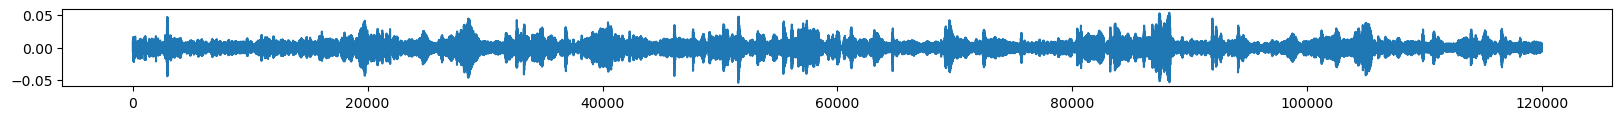

Finished epoch number 1 with a total of 10000 debug_seqs
 time: 2025-10-08 17:26:03.276719, epoch 2,  Loss: 0.2843
  Quantizer 0 Loss: 4.2477
  Quantizer 1 Loss: 4.3595
  Quantizer 2 Loss: 4.5418
  Quantizer 3 Loss: 4.5938
  Quantizer 4 Loss: 4.7243
  Quantizer 5 Loss: 4.8386
  Quantizer 6 Loss: 4.9515
  Quantizer 7 Loss: 5.0247
DEVICE going in: model tensors cuda:0, enc_model cuda:0, c cuda:0
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (120000,)


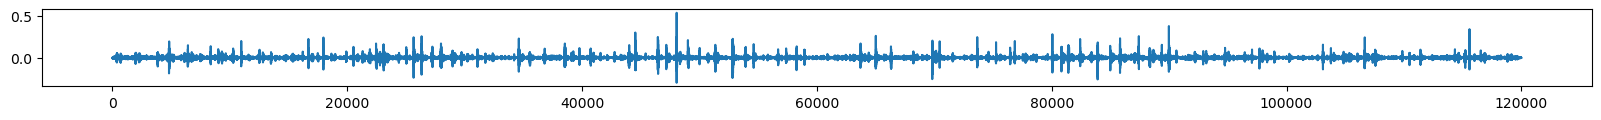

Finished epoch number 2 with a total of 10000 debug_seqs
 time: 2025-10-08 17:26:24.145438, epoch 3,  Loss: 0.2742
  Quantizer 0 Loss: 4.1306
  Quantizer 1 Loss: 4.1884
  Quantizer 2 Loss: 4.3333
  Quantizer 3 Loss: 4.3494
  Quantizer 4 Loss: 4.4512
  Quantizer 5 Loss: 4.5420
  Quantizer 6 Loss: 4.6381
  Quantizer 7 Loss: 4.7074
DEVICE going in: model tensors cuda:0, enc_model cuda:0, c cuda:0
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (120000,)


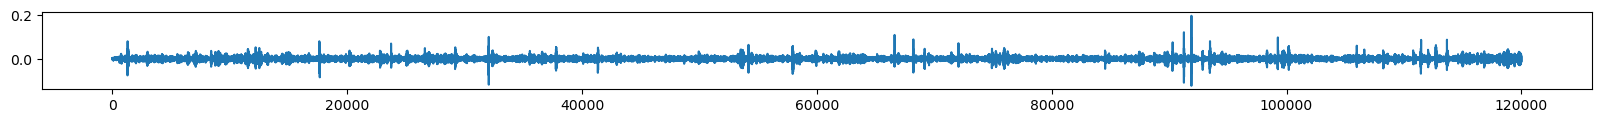

Finished epoch number 3 with a total of 10000 debug_seqs
 time: 2025-10-08 17:26:45.145776, epoch 4,  Loss: 0.2651
  Quantizer 0 Loss: 4.0604
  Quantizer 1 Loss: 4.0906
  Quantizer 2 Loss: 4.2011
  Quantizer 3 Loss: 4.1936
  Quantizer 4 Loss: 4.2738
  Quantizer 5 Loss: 4.3415
  Quantizer 6 Loss: 4.4202
  Quantizer 7 Loss: 4.4887
DEVICE going in: model tensors cuda:0, enc_model cuda:0, c cuda:0
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (120000,)


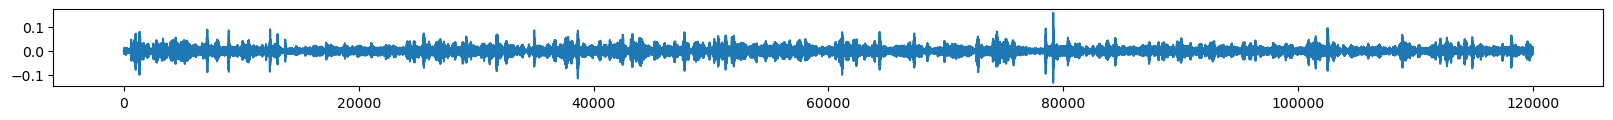

Finished epoch number 4 with a total of 10000 debug_seqs
 time: 2025-10-08 17:27:06.197493, epoch 5,  Loss: 0.2589
  Quantizer 0 Loss: 3.9892
  Quantizer 1 Loss: 4.0047
  Quantizer 2 Loss: 4.0889
  Quantizer 3 Loss: 4.0637
  Quantizer 4 Loss: 4.1313
  Quantizer 5 Loss: 4.1768
  Quantizer 6 Loss: 4.2450
  Quantizer 7 Loss: 4.3078
DEVICE going in: model tensors cuda:0, enc_model cuda:0, c cuda:0
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (120000,)


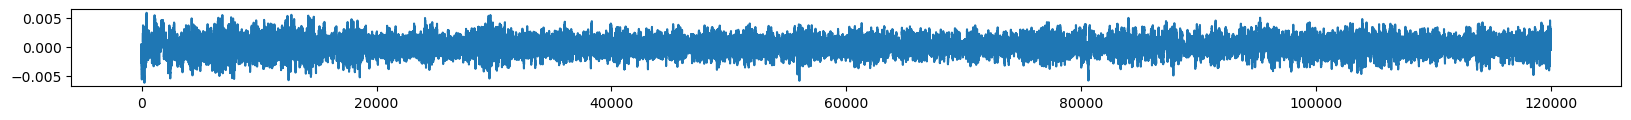

Finished epoch number 5 with a total of 10000 debug_seqs
 time: 2025-10-08 17:27:27.292890, epoch 6,  Loss: 0.2520
  Quantizer 0 Loss: 3.9237
  Quantizer 1 Loss: 3.9198
  Quantizer 2 Loss: 3.9840
  Quantizer 3 Loss: 3.9467
  Quantizer 4 Loss: 3.9954
  Quantizer 5 Loss: 4.0236
  Quantizer 6 Loss: 4.0840
  Quantizer 7 Loss: 4.1437
DEVICE going in: model tensors cuda:0, enc_model cuda:0, c cuda:0
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (120000,)


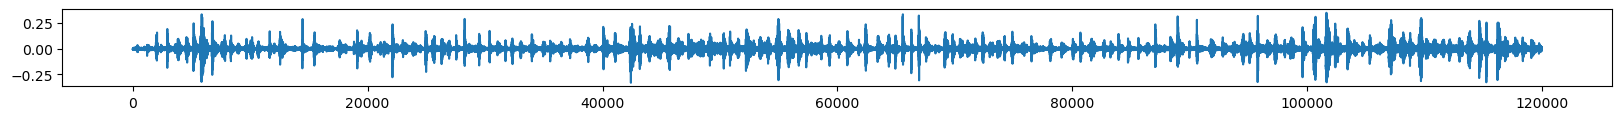

Finished epoch number 6 with a total of 10000 debug_seqs
 time: 2025-10-08 17:27:48.403881, epoch 7,  Loss: 0.2442
  Quantizer 0 Loss: 3.8667
  Quantizer 1 Loss: 3.8388
  Quantizer 2 Loss: 3.8862
  Quantizer 3 Loss: 3.8418
  Quantizer 4 Loss: 3.8825
  Quantizer 5 Loss: 3.8989
  Quantizer 6 Loss: 3.9444
  Quantizer 7 Loss: 4.0080
DEVICE going in: model tensors cuda:0, enc_model cuda:0, c cuda:0
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (120000,)


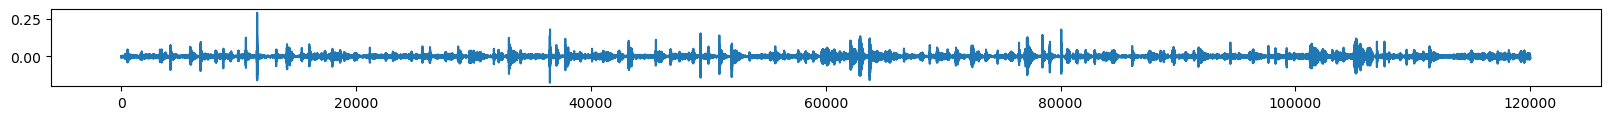

Finished epoch number 7 with a total of 10000 debug_seqs
 time: 2025-10-08 17:28:09.590950, epoch 8,  Loss: 0.2407
  Quantizer 0 Loss: 3.8089
  Quantizer 1 Loss: 3.7644
  Quantizer 2 Loss: 3.8004
  Quantizer 3 Loss: 3.7479
  Quantizer 4 Loss: 3.7825
  Quantizer 5 Loss: 3.7835
  Quantizer 6 Loss: 3.8226
  Quantizer 7 Loss: 3.8811
DEVICE going in: model tensors cuda:0, enc_model cuda:0, c cuda:0
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (120000,)


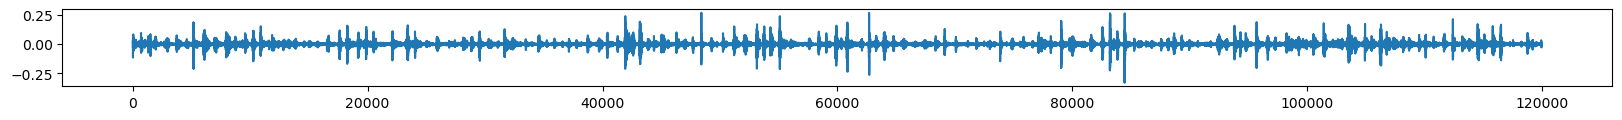

Finished epoch number 8 with a total of 10000 debug_seqs
 time: 2025-10-08 17:28:30.795756, epoch 9,  Loss: 0.2346
  Quantizer 0 Loss: 3.7526
  Quantizer 1 Loss: 3.6943
  Quantizer 2 Loss: 3.7195
  Quantizer 3 Loss: 3.6610
  Quantizer 4 Loss: 3.6883
  Quantizer 5 Loss: 3.6833
  Quantizer 6 Loss: 3.7151
  Quantizer 7 Loss: 3.7738
DEVICE going in: model tensors cuda:0, enc_model cuda:0, c cuda:0
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (120000,)


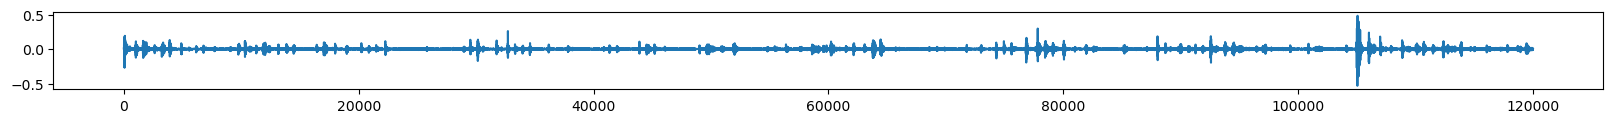

Finished epoch number 9 with a total of 10000 debug_seqs
 time: 2025-10-08 17:28:52.198255, epoch 10,  Loss: 0.2289
  Quantizer 0 Loss: 3.6950
  Quantizer 1 Loss: 3.6183
  Quantizer 2 Loss: 3.6366
  Quantizer 3 Loss: 3.5794
  Quantizer 4 Loss: 3.5998
  Quantizer 5 Loss: 3.5880
  Quantizer 6 Loss: 3.6140
  Quantizer 7 Loss: 3.6764
DEVICE going in: model tensors cuda:0, enc_model cuda:0, c cuda:0
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (120000,)


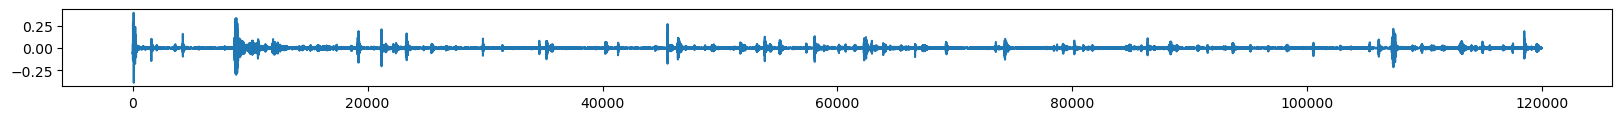

Finished epoch number 10 with a total of 10000 debug_seqs
 time: 2025-10-08 17:29:13.422792, epoch 11,  Loss: 0.2273
  Quantizer 0 Loss: 3.6405
  Quantizer 1 Loss: 3.5533
  Quantizer 2 Loss: 3.5610
  Quantizer 3 Loss: 3.4971
  Quantizer 4 Loss: 3.5229
  Quantizer 5 Loss: 3.5018
  Quantizer 6 Loss: 3.5217
  Quantizer 7 Loss: 3.5821
DEVICE going in: model tensors cuda:0, enc_model cuda:0, c cuda:0
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (120000,)


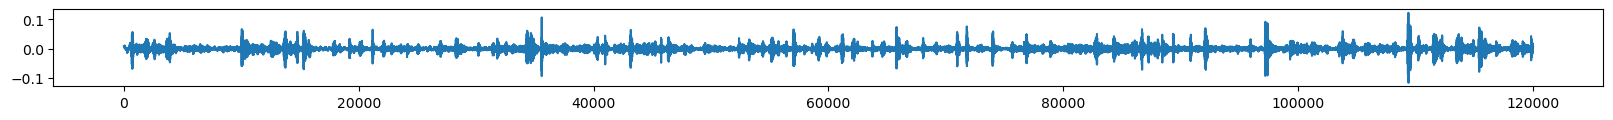

Finished epoch number 11 with a total of 10000 debug_seqs
 time: 2025-10-08 17:29:34.628674, epoch 12,  Loss: 0.2236
  Quantizer 0 Loss: 3.5948
  Quantizer 1 Loss: 3.4946
  Quantizer 2 Loss: 3.5004
  Quantizer 3 Loss: 3.4352
  Quantizer 4 Loss: 3.4583
  Quantizer 5 Loss: 3.4356
  Quantizer 6 Loss: 3.4471
  Quantizer 7 Loss: 3.5068
DEVICE going in: model tensors cuda:0, enc_model cuda:0, c cuda:0
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (120000,)


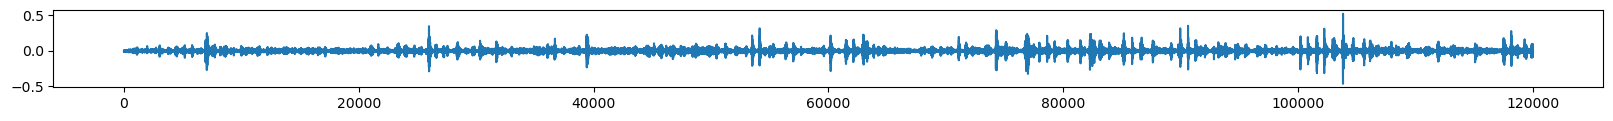

Finished epoch number 12 with a total of 10000 debug_seqs
 time: 2025-10-08 17:29:55.809288, epoch 13,  Loss: 0.2158
  Quantizer 0 Loss: 3.5384
  Quantizer 1 Loss: 3.4272
  Quantizer 2 Loss: 3.4278
  Quantizer 3 Loss: 3.3603
  Quantizer 4 Loss: 3.3842
  Quantizer 5 Loss: 3.3582
  Quantizer 6 Loss: 3.3680
  Quantizer 7 Loss: 3.4336
DEVICE going in: model tensors cuda:0, enc_model cuda:0, c cuda:0
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (120000,)


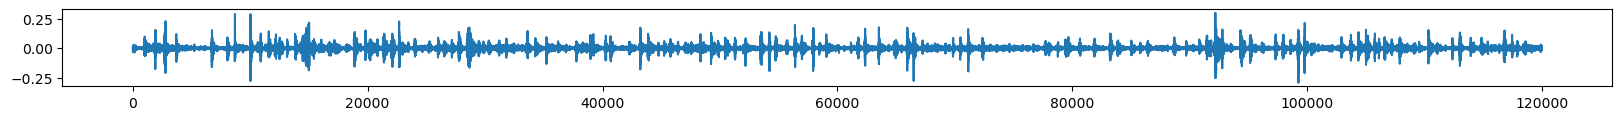

Finished epoch number 13 with a total of 10000 debug_seqs
 time: 2025-10-08 17:30:17.035638, epoch 14,  Loss: 0.2128
  Quantizer 0 Loss: 3.4960
  Quantizer 1 Loss: 3.3659
  Quantizer 2 Loss: 3.3616
  Quantizer 3 Loss: 3.3007
  Quantizer 4 Loss: 3.3193
  Quantizer 5 Loss: 3.2931
  Quantizer 6 Loss: 3.2992
  Quantizer 7 Loss: 3.3598
DEVICE going in: model tensors cuda:0, enc_model cuda:0, c cuda:0
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (120000,)


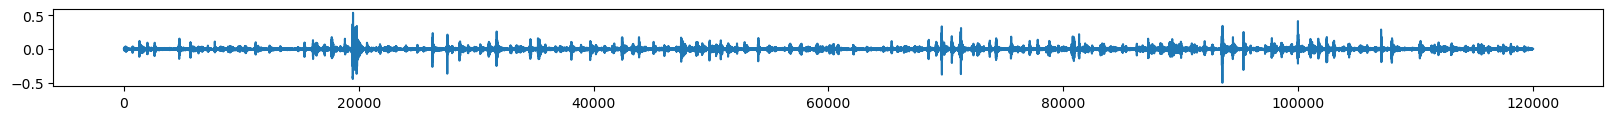

Finished epoch number 14 with a total of 10000 debug_seqs
 time: 2025-10-08 17:30:38.337017, epoch 15,  Loss: 0.2115
  Quantizer 0 Loss: 3.4524
  Quantizer 1 Loss: 3.3092
  Quantizer 2 Loss: 3.3045
  Quantizer 3 Loss: 3.2446
  Quantizer 4 Loss: 3.2654
  Quantizer 5 Loss: 3.2385
  Quantizer 6 Loss: 3.2363
  Quantizer 7 Loss: 3.2996
DEVICE going in: model tensors cuda:0, enc_model cuda:0, c cuda:0
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (120000,)


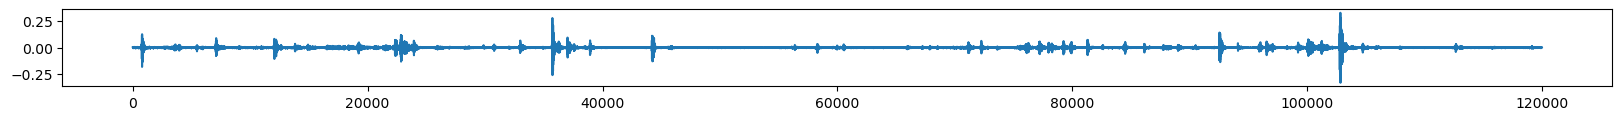

Finished epoch number 15 with a total of 10000 debug_seqs
 time: 2025-10-08 17:30:59.551622, epoch 16,  Loss: 0.2071
  Quantizer 0 Loss: 3.4213
  Quantizer 1 Loss: 3.2705
  Quantizer 2 Loss: 3.2576
  Quantizer 3 Loss: 3.1994
  Quantizer 4 Loss: 3.2215
  Quantizer 5 Loss: 3.1895
  Quantizer 6 Loss: 3.1873
  Quantizer 7 Loss: 3.2552
DEVICE going in: model tensors cuda:0, enc_model cuda:0, c cuda:0
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (120000,)


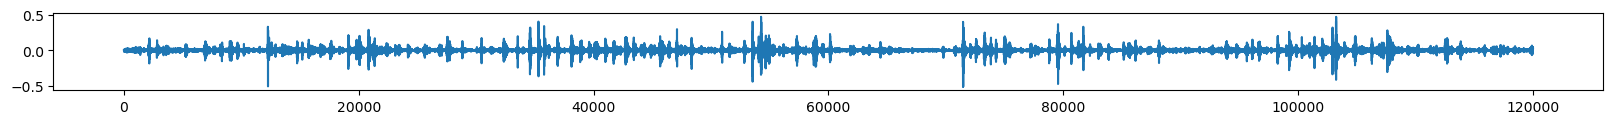

Finished epoch number 16 with a total of 10000 debug_seqs
 time: 2025-10-08 17:31:20.932122, epoch 17,  Loss: 0.2071
  Quantizer 0 Loss: 3.3857
  Quantizer 1 Loss: 3.2236
  Quantizer 2 Loss: 3.2118
  Quantizer 3 Loss: 3.1535
  Quantizer 4 Loss: 3.1797
  Quantizer 5 Loss: 3.1407
  Quantizer 6 Loss: 3.1407
  Quantizer 7 Loss: 3.2098
DEVICE going in: model tensors cuda:0, enc_model cuda:0, c cuda:0
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (120000,)


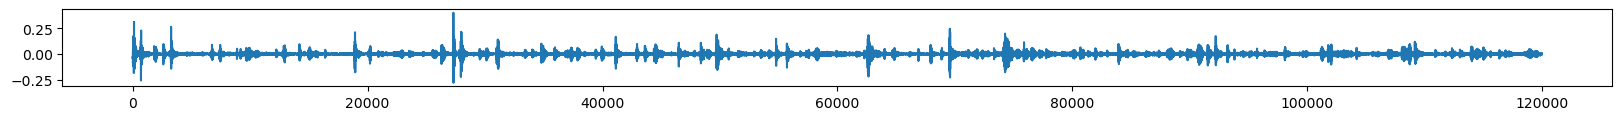

Finished epoch number 17 with a total of 10000 debug_seqs
 time: 2025-10-08 17:31:42.343004, epoch 18,  Loss: 0.2025
  Quantizer 0 Loss: 3.3614
  Quantizer 1 Loss: 3.1878
  Quantizer 2 Loss: 3.1787
  Quantizer 3 Loss: 3.1193
  Quantizer 4 Loss: 3.1425
  Quantizer 5 Loss: 3.1096
  Quantizer 6 Loss: 3.1097
  Quantizer 7 Loss: 3.1758
DEVICE going in: model tensors cuda:0, enc_model cuda:0, c cuda:0
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (120000,)


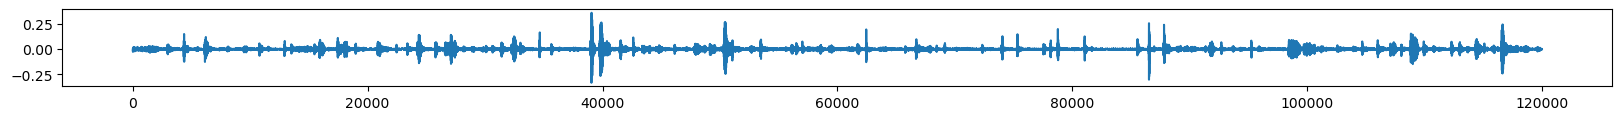

Finished epoch number 18 with a total of 10000 debug_seqs
 time: 2025-10-08 17:32:03.955967, epoch 19,  Loss: 0.2010
  Quantizer 0 Loss: 3.3316
  Quantizer 1 Loss: 3.1483
  Quantizer 2 Loss: 3.1377
  Quantizer 3 Loss: 3.0833
  Quantizer 4 Loss: 3.1066
  Quantizer 5 Loss: 3.0700
  Quantizer 6 Loss: 3.0736
  Quantizer 7 Loss: 3.1409
DEVICE going in: model tensors cuda:0, enc_model cuda:0, c cuda:0
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (120000,)


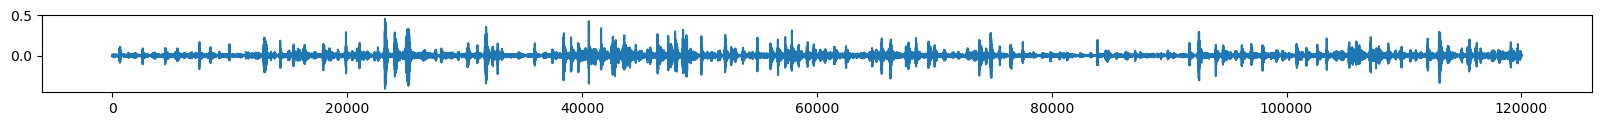

Finished epoch number 19 with a total of 10000 debug_seqs
 time: 2025-10-08 17:32:25.328727, epoch 20,  Loss: 0.2010
  Quantizer 0 Loss: 3.3065
  Quantizer 1 Loss: 3.1136
  Quantizer 2 Loss: 3.1036
  Quantizer 3 Loss: 3.0460
  Quantizer 4 Loss: 3.0742
  Quantizer 5 Loss: 3.0387
  Quantizer 6 Loss: 3.0368
  Quantizer 7 Loss: 3.1031
DEVICE going in: model tensors cuda:0, enc_model cuda:0, c cuda:0
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (120000,)


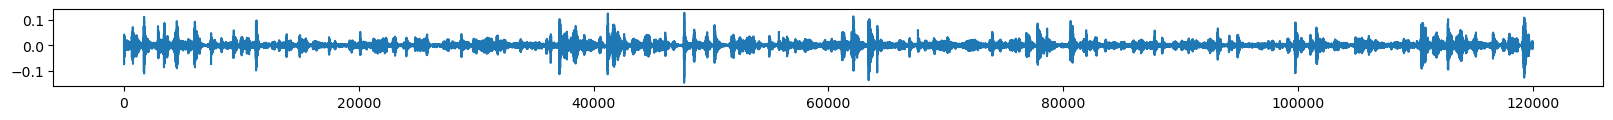

Finished epoch number 20 with a total of 10000 debug_seqs
 time: 2025-10-08 17:32:46.648651, epoch 21,  Loss: 0.1974
  Quantizer 0 Loss: 3.2815
  Quantizer 1 Loss: 3.0868
  Quantizer 2 Loss: 3.0754
  Quantizer 3 Loss: 3.0185
  Quantizer 4 Loss: 3.0502
  Quantizer 5 Loss: 3.0141
  Quantizer 6 Loss: 3.0142
  Quantizer 7 Loss: 3.0746
DEVICE going in: model tensors cuda:0, enc_model cuda:0, c cuda:0
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (120000,)


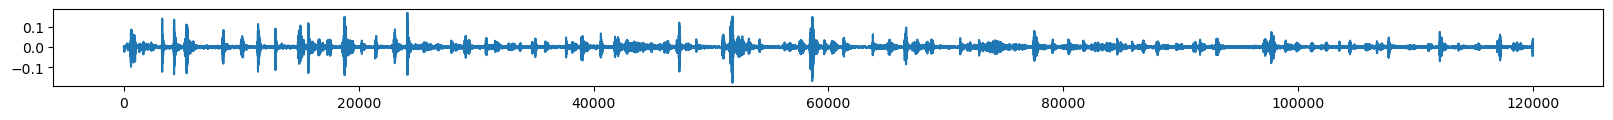

Finished epoch number 21 with a total of 10000 debug_seqs
 time: 2025-10-08 17:33:08.054060, epoch 22,  Loss: 0.1960
  Quantizer 0 Loss: 3.2582
  Quantizer 1 Loss: 3.0556
  Quantizer 2 Loss: 3.0438
  Quantizer 3 Loss: 2.9932
  Quantizer 4 Loss: 3.0214
  Quantizer 5 Loss: 2.9838
  Quantizer 6 Loss: 2.9833
  Quantizer 7 Loss: 3.0482
DEVICE going in: model tensors cuda:0, enc_model cuda:0, c cuda:0
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (120000,)


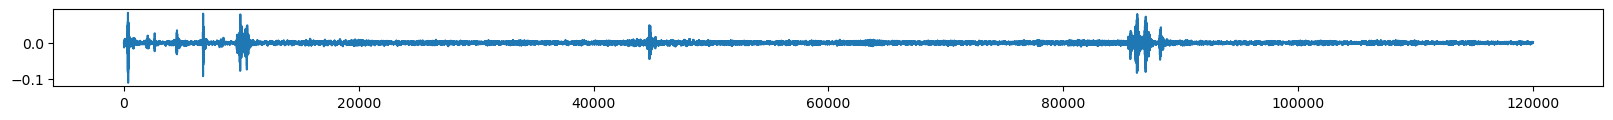

Finished epoch number 22 with a total of 10000 debug_seqs
 time: 2025-10-08 17:33:29.404506, epoch 23,  Loss: 0.1956
  Quantizer 0 Loss: 3.2386
  Quantizer 1 Loss: 3.0256
  Quantizer 2 Loss: 3.0151
  Quantizer 3 Loss: 2.9632
  Quantizer 4 Loss: 2.9975
  Quantizer 5 Loss: 2.9588
  Quantizer 6 Loss: 2.9553
  Quantizer 7 Loss: 3.0221
DEVICE going in: model tensors cuda:0, enc_model cuda:0, c cuda:0
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])
plot the audio which has shape (120000,)


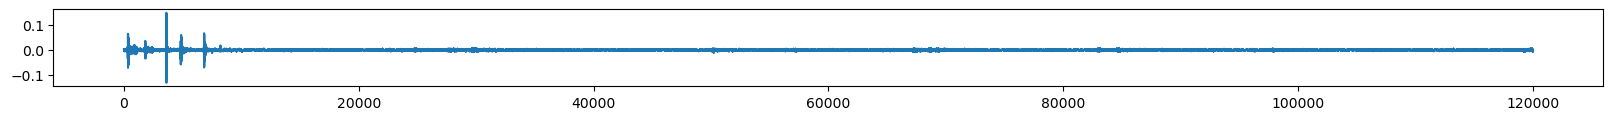

In [ ]:
# Train!
#*************************************
enc_model.to(device)
list_of_losses = []

print('{:%Y-%m-%d %H:%M:%S} Starting training...'.format(datetime.now()))
start_time = time.monotonic()
#-------------------------------------------------------------------------------
for epoch in range(start_epoch, start_epoch+params['num_epochs']):
    train(rnn,enc_model,epoch)
#-------------------------------------------------------------------------------
writer.close()
elapsed_time = time.monotonic() - start_time
print('Training time taken:',time_taken(elapsed_time))

#Just make sure the final model gets saved
checkpoint_data = {
    'epoch': epoch+1,
    'model_state_dict': rnn.state_dict(),
    'optimizer_state_dict': optimizer.state_dict()
}
# Save numbered checkpoint
numbered_path = os.path.join(f"{out_dir}/checkpoints", f"checkpoint_{epoch+1}.pt")
torch.save(checkpoint_data, numbered_path)
print(f"Saved checkpoint at epoch {epoch+1}")
# Copy to "last" (much faster than saving twice)
last_path = os.path.join(f"{out_dir}/checkpoints", "last_checkpoint.pt")
shutil.copy2(numbered_path, last_path)


In [ ]:
# Plot the loss over time
#*************************************
plt.figure()
plt.plot(list_of_losses)
plt.show()  # This will actually display the plot

In [ ]:
list_of_losses